# LLM 실험 결과 분석 노트북 - 상세 설명

## 이 노트북의 목적
LLM(GPT-4o, Solar) 기반 피드백 분류 실험의 결과를 종합 분석하고,
기존 ML(SVM) 및 BERT(KLUE-RoBERTa) 접근법과 비교합니다.

## 분석 항목 설명

### 성능 지표
- **Accuracy(정확도)**: 전체 샘플 중 올바르게 예측한 비율
- **F1 Macro**: 클래스별 F1 점수의 산술 평균 (소수 클래스에 동등한 가중치)
- **Cohen's Kappa**: 우연 일치를 보정한 일치도 (0.6 이상이면 "상당한 일치")
- **n_fail**: LLM이 유효한 레이블을 반환하지 못한 파싱 실패 횟수

### 프롬프트 진화 과정
| 단계 | 프롬프트 | 핵심 변경 | 왜 변경했는가 |
|------|----------|-----------|---------------|
| P0 | 제로샷 | 루브릭만 제공 | 기본 성능 측정 (baseline) |
| P1~P2 | CoT+퓨샷 | 예시와 사고 과정 추가 | P0에서 경계 레이블 구분 실패 |
| P9 | Hard Tiebreaker | 3/4/5 구분 규칙 추가 | P2에서도 3↔4↔5 혼동 지속 |

### 세 접근법 비교 (최종 결과)
| 접근법 | 최고 모델 | F1 Macro | Kappa | 특징 |
|--------|-----------|----------|-------|------|
| BERT | KLUE-RoBERTa | 0.93 | 0.93 | 학습 필요, 최고 성능 |
| ML | SVM (Linear) | 0.78 | 0.80 | 학습 필요, 빠른 실행 |
| LLM | GPT-4o (P9) | 0.68 | 0.65 | 학습 불필요, 비용 발생 |

## 1. 환경 설정

필요한 라이브러리와 경로를 설정합니다.
- `src/` 모듈: 설정(Config), 시각화 유틸리티(plot_confusion_matrix 등)
- `RUNS_DIR`: 실험 결과가 저장된 디렉토리 (각 실행별 하위 폴더 포함)
- 한글 폰트 설정: matplotlib에서 한글이 깨지지 않도록 시스템별 폰트 지정

## 1. 환경 설정

## 2. 데이터 분할 선택 및 결과 로드

실험 결과 파일을 자동으로 탐색하여 최신 버전을 로드합니다.
- `predictions`: 샘플별 예측 상세 (실제 레이블, 예측 레이블, 원본 LLM 응답)
- `metrics`: 실험별 성능 요약 (Accuracy, F1, Kappa 등)
- `run_metrics`: 실행별(run) 성능 (3회 반복 각각의 결과)
- 여러 소스(solar, final, llm 등)의 결과를 하나로 통합하여 비교 분석

## 2. 데이터 분할 선택 및 결과 로드

In [85]:
# ============================================================
# 결과 파일 자동 로드 (results/metrics 최신 버전)
# ============================================================
from datetime import datetime
import re

RESULTS_DIR = BASE_DIR / 'results' / 'metrics'
print(f"Results directory: {RESULTS_DIR}")

# ------------------------------------------------------------
# (선택) 특정 실험만 보고 싶을 때 아래를 해제해서 사용
# ------------------------------------------------------------
# SELECT_PREFIXES = ['final', 'solar']  # 예: final, solar, llm, kllm
# SELECT_PREDICTIONS_FILE = RESULTS_DIR / 'final_predictions_YYYYMMDD_HHMMSS.csv'
# SELECT_RUN_METRICS_FILE = RESULTS_DIR / 'final_run_metrics_YYYYMMDD_HHMMSS.csv'
# SELECT_METRICS_FILE = RESULTS_DIR / 'llm_metrics_YYYYMMDD_HHMMSS.csv'

SELECT_PREFIXES = None
SELECT_PREDICTIONS_FILE = None
SELECT_RUN_METRICS_FILE = None
SELECT_METRICS_FILE = None


def _latest_files(kind: str):
    pattern = f"*_{kind}_*.csv"
    files = list(RESULTS_DIR.glob(pattern))
    groups = {}

    for f in files:
        m = re.match(rf"(?P<prefix>.+)_{kind}_(\d{{8}}_\d{{6}})\.csv$", f.name)
        if not m:
            continue
        prefix = m.group('prefix')
        ts = m.group(2)
        groups.setdefault(prefix, []).append((ts, f))

    latest = {}
    for prefix, items in groups.items():
        items.sort(key=lambda x: x[0])
        latest[prefix] = items[-1][1]

    return latest


def _apply_filter(files_dict, manual_file=None):
    if manual_file:
        return {'manual': Path(manual_file)}
    if SELECT_PREFIXES:
        return {p: files_dict[p] for p in SELECT_PREFIXES if p in files_dict}
    return files_dict


pred_files = _apply_filter(_latest_files('predictions'), SELECT_PREDICTIONS_FILE)
run_metrics_files = _apply_filter(_latest_files('run_metrics'), SELECT_RUN_METRICS_FILE)
metrics_files = _apply_filter(_latest_files('metrics'), SELECT_METRICS_FILE)

print('선택된 predictions 파일:')
for k, v in pred_files.items():
    print('  ', k, v.name)

print('선택된 run_metrics 파일:')
for k, v in run_metrics_files.items():
    print('  ', k, v.name)

print('선택된 metrics 파일:')
for k, v in metrics_files.items():
    print('  ', k, v.name)


Results directory: <PROJECT_ROOT>/01_Analysis/03_LLM/results/metrics
선택된 predictions 파일:
   solar solar_predictions_20260126_155934.csv
   final final_predictions_20260126_170028.csv
   llm llm_predictions_20260126_155934.csv
선택된 run_metrics 파일:
   final final_run_metrics_20260126_170028.csv
선택된 metrics 파일:
   solar solar_metrics_20260126_155934.csv
   llm llm_metrics_20260126_155934.csv
   final_run final_run_metrics_20260126_170028.csv


In [86]:
# 결과 파일 로드 (latest)

def _load_concat(files_dict, tag_col='source'):
    if not files_dict:
        return None
    dfs = []
    for prefix, path in files_dict.items():
        try:
            df = pd.read_csv(path)
            df[tag_col] = prefix
            dfs.append(df)
        except Exception as e:
            print(f"로드 실패: {path} -> {e}")
    return pd.concat(dfs, ignore_index=True) if dfs else None

predictions_df = _load_concat(pred_files)
run_metrics_df = _load_concat(run_metrics_files)
metrics_df = _load_concat(metrics_files)

# 컬럼 정규화
if predictions_df is not None:
    if 'prompt_id' not in predictions_df.columns and 'prompt_version' in predictions_df.columns:
        predictions_df['prompt_id'] = predictions_df['prompt_version']
    if 'prompt_version' not in predictions_df.columns and 'prompt_id' in predictions_df.columns:
        predictions_df['prompt_version'] = predictions_df['prompt_id']

if metrics_df is not None:
    if 'prompt_id' not in metrics_df.columns and 'prompt_version' in metrics_df.columns:
        metrics_df['prompt_id'] = metrics_df['prompt_version']
    if 'prompt_version' not in metrics_df.columns and 'prompt_id' in metrics_df.columns:
        metrics_df['prompt_version'] = metrics_df['prompt_id']
    if 'f1_macro' not in metrics_df.columns and 'macro_f1' in metrics_df.columns:
        metrics_df['f1_macro'] = metrics_df['macro_f1']

if run_metrics_df is not None:
    if 'prompt_id' not in run_metrics_df.columns and 'prompt_version' in run_metrics_df.columns:
        run_metrics_df['prompt_id'] = run_metrics_df['prompt_version']
    if 'prompt_version' not in run_metrics_df.columns and 'prompt_id' in run_metrics_df.columns:
        run_metrics_df['prompt_version'] = run_metrics_df['prompt_id']
    if 'f1_macro' not in run_metrics_df.columns and 'macro_f1' in run_metrics_df.columns:
        run_metrics_df['f1_macro'] = run_metrics_df['macro_f1']
    if 'n' not in run_metrics_df.columns and 'n_samples' in run_metrics_df.columns:
        run_metrics_df['n'] = run_metrics_df['n_samples']

# run_number 보강 (predictions_df)
if predictions_df is not None and 'run_number' not in predictions_df.columns:
    if run_metrics_df is not None and 'run_id' in run_metrics_df.columns:
        map_cols = ['run_id', 'run_number', 'model', 'prompt_version']
        map_cols = [c for c in map_cols if c in run_metrics_df.columns]
        if set(['run_id', 'run_number']).issubset(run_metrics_df.columns):
            rn_map = run_metrics_df[map_cols].drop_duplicates()
            predictions_df = predictions_df.merge(
                rn_map,
                on=[c for c in ['run_id','model','prompt_version'] if c in rn_map.columns],
                how='left'
            )
    if 'run_number' not in predictions_df.columns and 'run_id' in predictions_df.columns:
        rn_map = predictions_df[['model','prompt_version','run_id']].drop_duplicates()
        rn_map = rn_map.sort_values('run_id')
        rn_map['run_number'] = rn_map.groupby(['model','prompt_version']).cumcount() + 1
        predictions_df = predictions_df.merge(rn_map, on=['model','prompt_version','run_id'], how='left')

# metrics_df 통합 (metrics + run_metrics)
metrics_frames = []
if metrics_df is not None:
    m = metrics_df.copy()
    m['source_kind'] = 'metrics'
    metrics_frames.append(m)
if run_metrics_df is not None:
    rm = run_metrics_df.copy()
    rm['source_kind'] = 'run_metrics'
    metrics_frames.append(rm)
metrics_df = pd.concat(metrics_frames, ignore_index=True) if metrics_frames else None

print('\n로드 완료:')
print('  metrics_df:', 0 if metrics_df is None else len(metrics_df))
print('  run_metrics_df:', 0 if run_metrics_df is None else len(run_metrics_df))
print('  predictions_df:', 0 if predictions_df is None else len(predictions_df))



로드 완료:
  metrics_df: 72
  run_metrics_df: 24
  predictions_df: 19968


## 3. 모델별 성능 분석

GPT-4o와 Solar-Pro2의 평균 성능을 비교합니다.
- F1 Macro, Accuracy, Kappa의 평균과 표준편차(3회 반복)
- GPT-4o가 모든 지표에서 Solar-Pro2보다 우수한 성능을 보임
- n_fail(파싱 실패): 두 모델 모두 0으로 안정적인 JSON 응답 생성

## 3. 모델별 성능 분석

In [88]:
if metrics_df is not None:
    # 모델별 평균 성능 (n_fail 포함)
    model_summary = metrics_df.groupby('model').agg({
        'accuracy': ['mean', 'std'],
        'f1_macro': ['mean', 'std'],
        'kappa': ['mean', 'std'],
        'n_fail': ['mean', 'sum']
    }).round(4)
    
    model_summary.columns = ['_'.join(col) for col in model_summary.columns]
    model_summary = model_summary.sort_values('f1_macro_mean', ascending=False)
    
    print("=== 모델별 평균 성능 ===")
    model_summary

=== 모델별 평균 성능 ===


## 4. 프롬프트별 성능 분석

프롬프트 진화에 따른 성능 변화를 분석합니다.
- **P0 (제로샷, Zero-shot)**: 예시 없이 루브릭만 제공 → 가장 낮은 성능
- **P1~P2 (CoT + 퓨샷, Few-shot)**: 예시와 단계적 사고 과정 추가 → 성능 향상
- **P9 (Hard Tiebreaker)**: 3/4/5 경계 구분 규칙 추가 → 최고 성능
- 히트맵: 모델×프롬프트 조합의 F1 성능을 한눈에 비교

## 4. 프롬프트별 성능 분석 (P1, P2 형식)

In [90]:
if metrics_df is not None:
    # 프롬프트별 평균 성능 (P1, P2 형식으로 표시, n_fail 포함)
    prompt_summary = metrics_df.groupby('prompt_id').agg({
        'accuracy': ['mean', 'std'],
        'f1_macro': ['mean', 'std'],
        'kappa': ['mean', 'std'],
        'n_fail': ['mean', 'sum']
    }).round(4)
    
    prompt_summary.columns = ['_'.join(col) for col in prompt_summary.columns]
    prompt_summary = prompt_summary.sort_values('f1_macro_mean', ascending=False)
    
    print("=== 프롬프트별 평균 성능 (P1, P2, ...) ===")
    prompt_summary

=== 프롬프트별 평균 성능 (P1, P2, ...) ===


## 5. 소수 클래스 성능 분석 (Class 0, 6)

데이터에서 적은 비율을 차지하는 레이블 0(무관)과 6(대안적 관점)의 성능을 분석합니다.
- **Class 0 (무관)**: 전체 2,080개 중 60개 (2.9%) - Recall 높지만 F1은 낮음
- **Class 6 (대안적 관점)**: 전체 2,080개 중 33개 (1.6%) - 가장 희소한 클래스
- 소수 클래스는 데이터가 적어 모든 접근법에서 성능이 낮은 경향
- LLM은 프롬프트에 해당 클래스의 정의를 명시하여 일정 수준의 성능 유지

## 5. 소수 클래스 성능 분석 (Class 0, 6)

In [92]:
# 소수 클래스 성능 계산 함수
def compute_minority_class_metrics(predictions_df):
    """
    예측 결과에서 소수 클래스(0, 6)의 recall, f1 계산
    (컬럼명: true_label/pred_label 또는 y_true/y_pred 모두 지원)
    """
    results = []

    # 컬럼명 통일
    df = predictions_df.copy()
    if 'true_label' not in df.columns and 'y_true' in df.columns:
        df['true_label'] = df['y_true']
    if 'pred_label' not in df.columns and 'y_pred' in df.columns:
        df['pred_label'] = df['y_pred']

    for (model, prompt_id, run_id), group in df.groupby(['model', 'prompt_id', 'run_id']):
        y_true = group['true_label'].values
        y_pred = group['pred_label'].values

        # 유효한 예측만 사용 (None/NA/-1 제외)
        valid_mask = []
        for p in y_pred:
            if p is None:
                valid_mask.append(False)
                continue
            if isinstance(p, str) and p.upper() == 'NA':
                valid_mask.append(False)
                continue
            try:
                valid_mask.append(int(p) != -1)
            except Exception:
                valid_mask.append(False)
        valid_mask = np.array(valid_mask, dtype=bool)

        y_true_valid = y_true[valid_mask]
        y_pred_valid = y_pred[valid_mask]

        if len(y_true_valid) == 0:
            continue

        # 전체 클래스 목록
        labels = list(range(7))

        # 클래스별 recall, f1 계산
        try:
            recalls = recall_score(y_true_valid, y_pred_valid, labels=labels, average=None, zero_division=0)
            f1s = f1_score(y_true_valid, y_pred_valid, labels=labels, average=None, zero_division=0)

            results.append({
                'model': model,
                'prompt_id': prompt_id,
                'run_id': run_id,
                'recall_0': recalls[0],
                'f1_0': f1s[0],
                'recall_6': recalls[6],
                'f1_6': f1s[6]
            })
        except Exception as e:
            print(f'소수 클래스 계산 실패: {model}, {prompt_id}, {run_id} -> {e}')
            continue

    return pd.DataFrame(results)


In [93]:
if predictions_df is not None:
    # 소수 클래스 메트릭 계산
    minority_metrics = compute_minority_class_metrics(predictions_df)
    print(f"소수 클래스 메트릭 계산 완료: {len(minority_metrics)} rows")

    # 모델-프롬프트별 소수 클래스 성능 요약
    minority_summary = minority_metrics.groupby(['model', 'prompt_id']).agg({
        'recall_0': 'mean',
        'f1_0': 'mean',
        'recall_6': 'mean',
        'f1_6': 'mean'
    }).round(4)

    minority_summary = minority_summary.sort_values(['model', 'f1_0', 'f1_6'], ascending=[True, False, False])

    print("=== 소수 클래스 성능 요약 (모델-프롬프트별) ===")
    print("Class 0: 비피드백 (희소 클래스)")
    print("Class 6: 무응답 (희소 클래스)")
    display(minority_summary)

    # 모델별 요약
    model_summary = minority_metrics.groupby(['model']).agg({
        'recall_0': 'mean',
        'f1_0': 'mean',
        'recall_6': 'mean',
        'f1_6': 'mean'
    }).round(4)

    print("\n=== 소수 클래스 성능 요약 (모델별) ===")
    display(model_summary)
else:
    print('predictions_df가 없습니다. 결과 로드 셀을 먼저 실행하세요.')


소수 클래스 메트릭 계산 완료: 8 rows
=== 소수 클래스 성능 요약 (모델-프롬프트별) ===
Class 0: 비피드백 (희소 클래스)
Class 6: 무응답 (희소 클래스)


recall_0    f1_0  recall_6    f1_6
model      prompt_id                                    
gpt-4o     P2_v3.0         1.0  0.7742    1.0000  0.9333
           P1_v2.0         1.0  0.7200    1.0000  0.8936
           P9_v1.0         1.0  0.4286    0.8571  0.6923
           P0_v2.0         1.0  0.4186    0.5238  0.6111
solar-pro2 P9_v1.0         1.0  0.6243    0.8095  0.7133
           P2_v3.0         1.0  0.6000    0.7460  0.7460
           P1_v2.0         1.0  0.5581    0.7143  0.6475
           P0_v2.0         1.0  0.3090    0.2222  0.3111


=== 소수 클래스 성능 요약 (모델별) ===


,recall_0,f1_0,recall_6,f1_6
model,,,,
gpt-4o,1.0,0.5853,0.8452,0.7826
solar-pro2,1.0,0.5229,0.6230,0.6045


## 6. 안정성 분석 (3회 반복)

LLM 예측의 안정성(재현성)을 분석합니다.
- **3회 일치율(pct_all_same)**: 동일 입력에 대해 3회 모두 같은 예측을 한 비율
- **Fleiss' Kappa**: 3명 이상의 평가자 간 일치도 (3회 반복을 평가자로 간주)
- **Krippendorff's Alpha**: 신뢰도 계수
- temperature=0 설정으로 높은 재현성이 기대되지만, API 서버 상태에 따라 미세한 차이 발생 가능
- 박스플롯: 3회 반복 간 F1 점수의 변동 범위를 시각화

## 6. 안정성 분석 (3회 반복)

wide table 저장: <PROJECT_ROOT>/01_Analysis/03_LLM/results/metrics/analysis_all_wide_20260126_211508.csv
=== 재현성 요약 (run 간 일치율/카파) ===


,model,prompt_version,pct_all_same,pct_run1_run2_same,pct_run1_run3_same,pct_run2_run3_same,pct_one_diff,pct_all_diff,kappa_1_2,kappa_1_3,kappa_2_3
0,gpt-4o,P0_v2.0,0.927885,0.939904,0.963942,0.947115,0.067308,0.004808,0.925057,0.954961,0.933895
1,gpt-4o,P1_v2.0,0.911058,0.932692,0.932692,0.956731,0.088942,0.000000,0.917488,0.917514,0.947005
2,gpt-4o,P2_v3.0,0.930288,0.944712,0.956731,0.951923,0.062500,0.007212,0.931737,0.946616,0.940681
3,gpt-4o,P9_v1.0,0.918269,0.942308,0.959135,0.935096,0.081731,0.000000,0.930417,0.950845,0.921748
4,solar-pro2,P0_v2.0,0.889423,0.925481,0.911058,0.942308,0.110577,0.000000,0.903655,0.885322,0.925528
5,solar-pro2,P1_v2.0,0.896635,0.951923,0.915865,0.925481,0.103365,0.000000,0.941347,0.897163,0.909025
6,solar-pro2,P2_v3.0,0.937500,0.975962,0.949519,0.949519,0.062500,0.000000,0.970458,0.938040,0.937989
7,solar-pro2,P9_v1.0,0.865385,0.927885,0.891827,0.908654,0.132212,0.002404,0.914002,0.869003,0.887671


=== Fleiss' kappa / Krippendorff's alpha ===


,model,prompt_version,fleiss_kappa,kripp_alpha
0,gpt-4o,P0_v2.0,0.937962,0.938012
1,gpt-4o,P1_v2.0,0.927333,0.927391
2,gpt-4o,P2_v3.0,0.939677,0.939726
3,gpt-4o,P9_v1.0,0.934343,0.934395
4,solar-pro2,P0_v2.0,0.904814,0.904891
5,solar-pro2,P1_v2.0,0.915854,0.915921
6,solar-pro2,P2_v3.0,0.948818,0.948860
7,solar-pro2,P9_v1.0,0.890340,0.890252


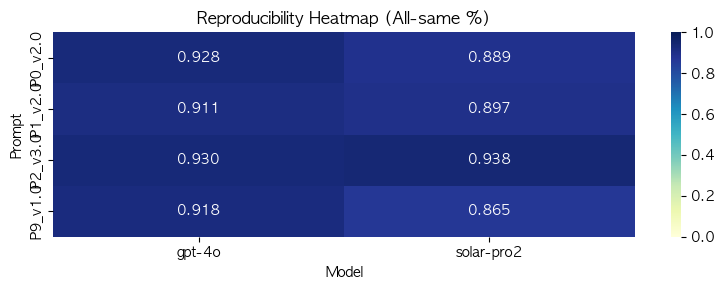

재현성 요약 저장: <PROJECT_ROOT>/01_Analysis/03_LLM/results/metrics/analysis_all_repro_20260126_211508.csv


In [95]:
# 안정성/재현성 분석 (3회 반복 기준)
if predictions_df is not None:
    # wide table 생성
    base = predictions_df[['model', 'prompt_version', 'sample_id', 'y_true']].drop_duplicates()

    pivot = predictions_df.pivot_table(
        index=['model', 'prompt_version', 'sample_id'],
        columns='run_number',
        values='y_pred',
        aggfunc='first'
    ).reset_index()

    # run_number 컬럼 정리
    run_cols = [c for c in pivot.columns if isinstance(c, (int, float))]
    run_cols = sorted([int(c) for c in run_cols])

    for r in run_cols:
        pivot.rename(columns={r: f'pred_run{r}'}, inplace=True)

    wide = base.merge(pivot, on=['model','prompt_version','sample_id'], how='left')

    # 불일치 표시
    for r in [1,2,3]:
        col = f'pred_run{r}'
        if col in wide.columns:
            wide[f'diff_true_run{r}'] = wide[col] != wide['y_true']

    # run 간 차이
    if 'pred_run1' in wide.columns and 'pred_run2' in wide.columns:
        wide['diff_run1_run2'] = wide['pred_run1'] != wide['pred_run2']
    if 'pred_run1' in wide.columns and 'pred_run3' in wide.columns:
        wide['diff_run1_run3'] = wide['pred_run1'] != wide['pred_run3']
    if 'pred_run2' in wide.columns and 'pred_run3' in wide.columns:
        wide['diff_run2_run3'] = wide['pred_run2'] != wide['pred_run3']

    # 저장
    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
    metrics_dir = RESULTS_DIR
    wide_path = metrics_dir / f'analysis_all_wide_{timestamp}.csv'
    wide.to_csv(wide_path, index=False, encoding='utf-8-sig')
    print(f"wide table 저장: {wide_path}")

    # 재현성 지표
    try:
        from sklearn.metrics import cohen_kappa_score
    except Exception:
        cohen_kappa_score = None

    wide['n_unique_runs'] = wide[[c for c in wide.columns if c.startswith('pred_run')]].nunique(axis=1, dropna=False)

    def pairwise_kappa(df, a, b):
        if cohen_kappa_score is None:
            return float('nan')
        sub = df[[a, b]].dropna()
        if len(sub) == 0:
            return float('nan')
        return cohen_kappa_score(sub[a], sub[b])

    repro_summary = []
    for (model, prompt), g in wide.groupby(['model','prompt_version']):
        agree_all = (g.get('pred_run1') == g.get('pred_run2')) & (g.get('pred_run1') == g.get('pred_run3'))
        agree12 = g.get('pred_run1') == g.get('pred_run2')
        agree13 = g.get('pred_run1') == g.get('pred_run3')
        agree23 = g.get('pred_run2') == g.get('pred_run3')

        repro_summary.append({
            'model': model,
            'prompt_version': prompt,
            'pct_all_same': agree_all.mean(),
            'pct_run1_run2_same': agree12.mean(),
            'pct_run1_run3_same': agree13.mean(),
            'pct_run2_run3_same': agree23.mean(),
            'pct_one_diff': (g['n_unique_runs'] == 2).mean(),
            'pct_all_diff': (g['n_unique_runs'] == 3).mean(),
            'kappa_1_2': pairwise_kappa(g, 'pred_run1', 'pred_run2'),
            'kappa_1_3': pairwise_kappa(g, 'pred_run1', 'pred_run3'),
            'kappa_2_3': pairwise_kappa(g, 'pred_run2', 'pred_run3'),
        })

    repro_df = pd.DataFrame(repro_summary)
    print('=== 재현성 요약 (run 간 일치율/카파) ===')
    display(repro_df)

    # Fleiss' kappa / Krippendorff's alpha (nominal)
    def fleiss_kappa_nominal(df, label_cols, labels=None):
        import numpy as np
        if labels is None:
            labels = sorted({int(x) for col in label_cols for x in df[col].dropna().unique()})
        label_to_idx = {l:i for i,l in enumerate(labels)}

        n = len(label_cols)
        if n < 2:
            return float('nan')

        P_i_list = []
        n_ij_sum = np.zeros(len(labels))
        n_total = 0

        for _, row in df[label_cols].iterrows():
            ratings = [row[c] for c in label_cols if pd.notna(row[c])]
            n_i = len(ratings)
            if n_i < 2:
                continue
            n_total += n_i
            counts = np.zeros(len(labels))
            for r in ratings:
                try:
                    idx = label_to_idx[int(r)]
                except Exception:
                    continue
                counts[idx] += 1
            n_ij_sum += counts
            P_i = (np.sum(counts * (counts - 1)) / (n_i * (n_i - 1)))
            P_i_list.append(P_i)

        if not P_i_list:
            return float('nan')

        P_bar = float(np.mean(P_i_list))
        p_j = n_ij_sum / n_total if n_total > 0 else np.zeros(len(labels))
        P_e = float(np.sum(p_j ** 2))
        if P_e == 1:
            return float('nan')
        return (P_bar - P_e) / (1 - P_e)

    def kripp_alpha_nominal(df, label_cols):
        import numpy as np
        Do_num = 0.0
        Do_den = 0.0
        value_counts = {}

        for _, row in df[label_cols].iterrows():
            ratings = [row[c] for c in label_cols if pd.notna(row[c])]
            n_i = len(ratings)
            if n_i < 2:
                continue
            counts = {}
            for r in ratings:
                try:
                    r = int(r)
                except Exception:
                    continue
                counts[r] = counts.get(r, 0) + 1
                value_counts[r] = value_counts.get(r, 0) + 1

            n_i = sum(counts.values())
            if n_i < 2:
                continue

            Do_den += n_i * (n_i - 1)
            Do_num += sum(v * (n_i - v) for v in counts.values())

        if Do_den == 0:
            return float('nan')

        Do = Do_num / Do_den
        n_total = sum(value_counts.values())
        if n_total < 2:
            return float('nan')
        De_num = sum(v * (n_total - v) for v in value_counts.values())
        De_den = n_total * (n_total - 1)
        De = De_num / De_den if De_den > 0 else float('nan')

        if De == 0:
            return float('nan')
        return 1 - (Do / De)

    label_cols = [c for c in wide.columns if c.startswith('pred_run')]
    repro_df['fleiss_kappa'] = repro_df.apply(
        lambda r: fleiss_kappa_nominal(
            wide[(wide['model'] == r['model']) & (wide['prompt_version'] == r['prompt_version'])],
            label_cols
        ),
        axis=1
    )
    repro_df['kripp_alpha'] = repro_df.apply(
        lambda r: kripp_alpha_nominal(
            wide[(wide['model'] == r['model']) & (wide['prompt_version'] == r['prompt_version'])],
            label_cols
        ),
        axis=1
    )

    print("=== Fleiss' kappa / Krippendorff's alpha ===")
    display(repro_df[['model','prompt_version','fleiss_kappa','kripp_alpha']])

    # 재현성 히트맵 (all-same 비율)
    try:
        heat = repro_df.pivot_table(
            index='prompt_version',
            columns='model',
            values='pct_all_same'
        )
        plt.figure(figsize=(8, max(3, len(heat) * 0.6)))
        sns.heatmap(heat, annot=True, fmt='.3f', cmap='YlGnBu', vmin=0, vmax=1)
        plt.title('Reproducibility Heatmap (All-same %)')
        plt.xlabel('Model')
        plt.ylabel('Prompt')
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print('히트맵 생성 실패:', e)

    # 재현성 요약 저장
    repro_path = metrics_dir / f'analysis_all_repro_{timestamp}.csv'
    repro_df.to_csv(repro_path, index=False, encoding='utf-8-sig')
    print(f'재현성 요약 저장: {repro_path}')
else:
    print('predictions_df가 없습니다. 결과 로드 셀을 먼저 실행하세요.')


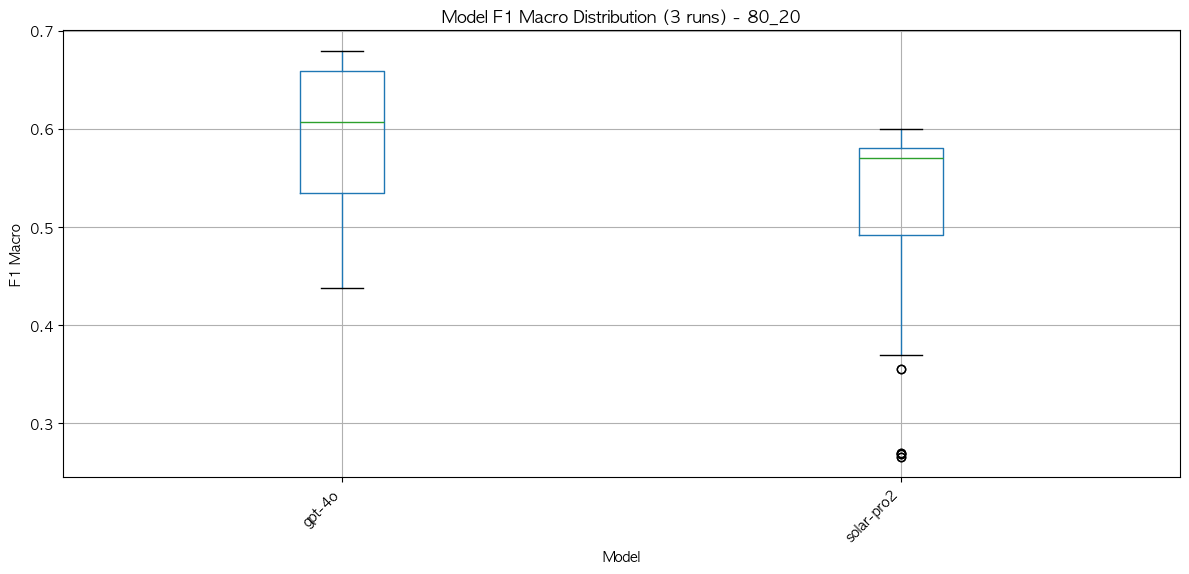

In [96]:
if metrics_df is not None:
    # 반복 실행 간 변동성 시각화
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # 박스플롯
    metrics_df.boxplot(
        column='f1_macro',
        by='model',
        ax=ax
    )
    
    ax.set_title(f'Model F1 Macro Distribution (3 runs) - {SPLIT_OPTION}')
    ax.set_xlabel('Model')
    ax.set_ylabel('F1 Macro')
    plt.suptitle('')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

## 7. ML/BERT와 비교

세 가지 접근법의 최고 성능을 비교합니다.
- **BERT (KLUE-RoBERTa)**: F1 = 0.93, Kappa = 0.93 → 최고 성능 (학습 데이터 필요)
- **ML (SVM Linear)**: F1 = 0.78, Kappa = 0.80 → 중간 성능 (TF-IDF 특성 추출)
- **LLM (GPT-4o + P9)**: F1 = 0.68, Kappa = 0.65 → 학습 불필요, API 비용 발생
- LLM의 장점: 새 도메인에 즉시 적용 가능, 라벨 데이터 없이도 분류 수행
- LLM의 단점: 절대 성능은 학습 기반 모델보다 낮음

## 7. ML/BERT와 비교

In [13]:
# ML 결과 로드
ml_results_path = DATA_DIR / '2_ml' / 'results' / 'baseline' / 'test_results.csv'
if ml_results_path.exists():
    ml_results = pd.read_csv(ml_results_path)
    # 컬럼명 통일
    if 'F1_Macro' not in ml_results.columns and 'macro_f1' in ml_results.columns:
        ml_results['F1_Macro'] = ml_results['macro_f1']
    if 'Kappa' not in ml_results.columns and 'kappa' in ml_results.columns:
        ml_results['Kappa'] = ml_results['kappa']
    if 'Model' not in ml_results.columns and 'model' in ml_results.columns:
        ml_results['Model'] = ml_results['model']

    ml_best = ml_results.loc[ml_results['F1_Macro'].idxmax()]
    print('=== ML 최고 성능 ===')
    print(f"모델: {ml_best['Model']}")
    print(f"Accuracy: {ml_best['Accuracy']:.4f}" if 'Accuracy' in ml_best else f"Accuracy: {ml_best.get('accuracy', float('nan')):.4f}")
    print(f"F1 Macro: {ml_best['F1_Macro']:.4f}")
    print(f"Cohen's Kappa: {ml_best['Kappa']:.4f}")
else:
    print(f"ML 결과 파일이 없습니다: {ml_results_path}")
    ml_best = None

# BERT 결과 로드
bert_results_path = DATA_DIR / '3_bert' / 'results' / 'baseline' / 'test_results.csv'
if bert_results_path.exists():
    bert_results = pd.read_csv(bert_results_path)
    # 컬럼명 통일
    if 'F1_Macro' not in bert_results.columns and 'macro_f1' in bert_results.columns:
        bert_results['F1_Macro'] = bert_results['macro_f1']
    if 'Kappa' not in bert_results.columns and 'kappa' in bert_results.columns:
        bert_results['Kappa'] = bert_results['kappa']
    if 'Model' not in bert_results.columns and 'model' in bert_results.columns:
        bert_results['Model'] = bert_results['model']

    bert_best = bert_results.loc[bert_results['F1_Macro'].idxmax()]
    print('\n=== BERT 최고 성능 ===')
    print(f"모델: {bert_best['Model']}")
    print(f"Accuracy: {bert_best['Accuracy']:.4f}" if 'Accuracy' in bert_best else f"Accuracy: {bert_best.get('accuracy', float('nan')):.4f}")
    print(f"F1 Macro: {bert_best['F1_Macro']:.4f}")
    print(f"Cohen's Kappa: {bert_best['Kappa']:.4f}")
else:
    print(f"BERT 결과 파일이 없습니다: {bert_results_path}")
    bert_best = None

=== ML 최고 성능 ===
모델: SVM (Linear)
Accuracy: 0.8413
F1 Macro: 0.7755
Cohen's Kappa: 0.7979

=== BERT 최고 성능 ===
모델: KLUE-RoBERTa
Accuracy: 0.9471
F1 Macro: 0.9270
Cohen's Kappa: 0.9313


## 8. 분할별 결과 비교 (80/20 vs 85/15)

훈련/테스트 데이터 분할 비율에 따른 성능 차이를 분석합니다.
- **80/20**: 훈련 80%, 테스트 20% (약 416개 테스트)
- **85/15**: 훈련 85%, 테스트 15% (약 312개 테스트)
- LLM은 학습 데이터를 사용하지 않으므로 분할 비율의 직접적 영향은 적음
  (테스트셋 구성의 차이만 영향)

## 8. 분할별 결과 비교 (80/20 vs 85/15)

## 9. 혼동 행렬 분석

최고 성능 모델-프롬프트 조합의 혼동 행렬(Confusion Matrix)을 시각화합니다.
- 대각선: 정확한 예측 (값이 클수록 좋음)
- 비대각선: 잘못된 예측 (어떤 레이블이 어떤 레이블로 혼동되는지 확인)
- 주요 혼동 패턴: 3↔4, 4↔5 간 혼동이 빈번 (경계 레이블 문제)

## 9. 혼동 행렬 분석

## 10. 결론

전체 LLM 실험의 핵심 발견을 요약합니다.
- **프롬프트 전략 효과**: P0(제로샷) → P9(Hard Tiebreaker)로 F1이 약 0.36 → 0.68로 향상
- **세 접근법 비교**: BERT(0.93) > ML(0.78) > LLM(0.68) (F1 Macro 기준)
- **LLM의 의의**: 학습 데이터 없이도 "상당한 수준"의 일치도 달성
- **한계**: 경계 레이블(3/4/5) 구분에서 여전히 인간 코더 수준에 미치지 못함

## 10. 결론

In [104]:
print("=" * 60)
print(f"LLM 기반 피드백 분류 실험 결론 ({SPLIT_OPTION})")
print("=" * 60)

if metrics_df is not None:
    print(f"\n1. 실험 규모")
    print(f"   - 총 실험 수: {len(metrics_df)}")
    print(f"   - 모델 수: {metrics_df['model'].nunique()}")
    print(f"   - 프롬프트 수: {metrics_df['prompt_id'].nunique()}")
    print(f"   - 반복 횟수: {metrics_df['run_id'].max()}")
    
    print(f"\n2. 최고 성능")
    print(f"   - 모델: {llm_best['model']}")
    print(f"   - 프롬프트: {llm_best['prompt_id']}")
    print(f"   - F1 Macro: {llm_best['f1_macro']:.4f}")
    print(f"   - n_fail: {llm_best.get('n_fail', 0)}")
    
    print(f"\n3. 프롬프트 전략 효과")
    best_prompt = prompt_summary.index[0]
    worst_prompt = prompt_summary.index[-1]
    print(f"   - 최적 프롬프트: {best_prompt}")
    print(f"   - 성능 범위: {prompt_summary.loc[worst_prompt, 'f1_macro_mean']:.4f} ~ {prompt_summary.loc[best_prompt, 'f1_macro_mean']:.4f}")
    
    if predictions_df is not None and len(minority_metrics) > 0:
        print(f"\n4. 소수 클래스 성능")
        avg_f1_0 = minority_metrics['f1_0'].mean()
        avg_f1_6 = minority_metrics['f1_6'].mean()
        print(f"   - Class 0 평균 F1: {avg_f1_0:.4f}")
        print(f"   - Class 6 평균 F1: {avg_f1_6:.4f}")

if comparison_data:
    print(f"\n5. 접근법 비교 (F1 Macro)")
    for _, row in comparison_df.iterrows():
        print(f"   - {row['Approach']}: {row['F1_Macro']:.4f}")

LLM 기반 피드백 분류 실험 결론 (80_20)

1. 실험 규모
   - 총 실험 수: 72
   - 모델 수: 2
   - 프롬프트 수: 4
   - 반복 횟수: 2026-01-26_P9_v1.0_solar-pro2_80_20

2. 최고 성능
   - 모델: gpt-4o
   - 프롬프트: P2_v3.0
   - F1 Macro: 0.6798
   - n_fail: 0

3. 프롬프트 전략 효과
   - 최적 프롬프트: P2_v3.0
   - 성능 범위: 0.3627 ~ 0.6143

4. 소수 클래스 성능
   - Class 0 평균 F1: 0.5541
   - Class 6 평균 F1: 0.6935

5. 접근법 비교 (F1 Macro)
   - ML: 0.7755
   - BERT: 0.9270
   - LLM: 0.6798
